<!--
  ============================================================================
  TAVIE_SSG_model_misspecification.ipynb  —  reproducibility notebook
  Figure 44 of the Supplementary Materials
  ============================================================================
-->

<h1 align="center">TAVIE-SSG under Likelihood Misspecification</h1>

<p align="center">
  <b>Reproducibility for the model misspecification study reported in the Section P Supplementary Materials</b><br>
  <i>TAVIE-SSG vs. PyMC NUTS &middot; six misspecified likelihoods &middot; fractional posteriors at five likelihood powers</i>
</p>

<p align="center">
  <img alt="Python" src="https://img.shields.io/badge/Python-3.12-3776AB?logo=python&logoColor=white">
  <img alt="Jupyter" src="https://img.shields.io/badge/Jupyter-Notebook-F37626?logo=jupyter&logoColor=white">
  <img alt="PyMC" src="https://img.shields.io/badge/PyMC-5.x-1E4C7E">
</p>

<p align="center">
  <a href="https://github.com/Roy-SR-007/TAVIE-SSG/blob/main/TAVIE_SSG_model_misspecification.ipynb"><img alt="nbviewer" src="https://img.shields.io/badge/render-nbviewer-F37726?logo=jupyter&logoColor=white"></a>
  <img alt="Data" src="https://img.shields.io/badge/data-simulated-005EA2">
</p>

---

### What this notebook does

This notebook studies predictive performance when the fitted likelihood differs from the
data-generating distribution. It compares **TAVIE-SSG** with the corresponding fractional
posterior **PyMC NUTS** fit in each of the following six experiments:

1. fit Laplace to Normal data;
2. fit Laplace to Student's-t data with $\nu=3$;
3. fit Laplace to Student's-t data with $\nu=8$;
4. fit Student's-t to Normal data;
5. fit Student's-t to Laplace data; and
6. fit Negative-Binomial to Poisson data.

The first five are Type I (location–scale) SSG experiments; the sixth is Type II. The
response MSE is computed in-sample from the posterior mean regression fit,

$$\operatorname{MSE}(y,\widehat y)=\frac{1}{n}\lVert y-\widehat y\rVert_2^2,$$

with $\widehat y$ using the posterior mean of $\beta$ for both methods. PyMC uses the same
likelihood, likelihood power $\alpha$, and prior as TAVIE-SSG, so the comparison isolates
the variational approximation from NUTS within each misspecified model. All generating
errors are centered and scaled to have variance $1/\tau^2_{\mathrm{true}}$, so differences
among cases reflect distributional shape and likelihood misspecification rather than a
change in marginal noise variance.

| | Specification |
|:--|:--|
| **Design** | $n = 200$, $p = 9$ (including intercept), $\boldsymbol\beta_{\mathrm{true}}$ held fixed across cases and repetitions |
| **Likelihood power** | $\alpha \in \{0.2,\ 0.5,\ 0.8,\ 0.95,\ 1.0\}$ |
| **Prior** | $\tau^{2} \sim \mathrm{Gamma}(a_0/2,\ b_0/2)$ and $\boldsymbol\beta \mid \tau^{2} \sim \mathcal{N}(0,\ \sigma^{2}_{\mathrm{prior}} I / \tau^{2})$, with $a_0 = b_0 = 0.05$ and $\sigma^{2}_{\mathrm{prior}} = 1$ |
| **Truth** | $\tau^{2}_{\mathrm{true}} = 3.0$; Student's-t fits use a fixed $\nu = 5$; the Type II case uses $r = 10$ |
| **Replicates** | 10 Monte Carlo repetitions, with common random numbers across $\alpha$ and both methods within a case and repetition |
| **NUTS settings** | 4,000 retained draws, 1,000 tuning draws, 2 chains, 1 core, `target_accept = 0.9` |
| **Methods** | TAVIE-SSG, PyMC NUTS |
| **Metric** | in-sample response MSE at the posterior mean of $\boldsymbol\beta$ |

> [!IMPORTANT]
> **To reproduce, run every cell in order, top to bottom.**

### Results generated in this notebook

| Main Manuscript | Supplementary Materials | Output file |
|:--:|:--:|:--|
| — | **Figure 44** | `tavie_ssg_misspecification_six_experiments_mse_boxplots.pdf` |

All files are written to `results_misspecified/`, including the two intermediate result
files `tavie_ssg_misspecification_tavie_nuts_mse.pkl` and
`tavie_ssg_misspecification_poisson_to_negbin_tavie_nuts_mse.pkl`.

In [8]:
# required imports
from pathlib import Path
import logging
import pickle
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from IPython.display import display
from tqdm.auto import trange

from TAVIE import TAVIE_loc_scale, TAVIE_type_II

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)

## Type I SSG misspecification experiments

## Simulation settings

The dimension and precision follow the existing Laplace and Student's-t simulation notebooks in this repository. TAVIE-SSG's Student's-t likelihood requires a fixed degree of freedom; `student_fit_nu=5` matches the existing Student's-t simulations.

The NUTS defaults also follow the repository's fractional posterior PyMC comparisons: 4,000 retained draws, 1,000 tuning draws, two chains, one core, and `target_accept=0.9`.

In [ ]:
# Fixed design and Monte Carlo settings
n = 200
total_p = 9  # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 8
n_reps = 10    
alphas = [0.2, 0.5, 0.8, 0.95, 1.0]
tau2_true = 3.0
student_fit_nu = 5
seed = 20260826

# Common Normal-Gamma prior used by both TAVIE-SSG and PyMC NUTS:
# tau2 ~ Gamma(a0/2, b0/2), beta | tau2 ~ N(0, prior_var * I / tau2).
prior_var = 1.0
a0 = 0.05
b0 = 0.05

# PyMC NUTS settings (matching the repository's fractional-posterior fits)
nuts_draws = 4000
nuts_tune = 1000
nuts_chains = 2
nuts_cores = 1
nuts_target_accept = 0.9

RESULTS_DIR = Path("results_misspecified")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_PATH = RESULTS_DIR / "tavie_ssg_misspecification_tavie_nuts_mse.pkl"
METHODS = ["TAVIE-SSG", "PyMC NUTS"]

# Hold beta_true fixed across cases and repetitions, as in the repository's
# existing simulation notebooks. A separate RNG keeps it independent of the data seeds.
beta_rng = np.random.default_rng(seed)
beta_true = beta_rng.normal(loc=0.0, scale=1.0, size=p + 1)

In [ ]:
EXPERIMENTS = [
    {
        "key": "laplace_on_normal",
        "label": "Laplace fit / Normal data",
        "fit_family": "laplace",
        "data_distribution": "normal",
        "data_nu": None,
        "fit_nu": None,
    },
    {
        "key": "laplace_on_student_t3",
        "label": r"Laplace fit / Student-t data ($\nu=3$)",
        "fit_family": "laplace",
        "data_distribution": "student",
        "data_nu": 3,
        "fit_nu": None,
    },
    {
        "key": "laplace_on_student_t8",
        "label": r"Laplace fit / Student-t data ($\nu=8$)",
        "fit_family": "laplace",
        "data_distribution": "student",
        "data_nu": 8,
        "fit_nu": None,
    },
    {
        "key": "student_t_on_normal",
        "label": rf"Student-t fit ($\nu={student_fit_nu}$) / Normal data",
        "fit_family": "student",
        "data_distribution": "normal",
        "data_nu": None,
        "fit_nu": student_fit_nu,
    },
    {
        "key": "student_t_on_laplace",
        "label": rf"Student-t fit ($\nu={student_fit_nu}$) / Laplace data",
        "fit_family": "student",
        "data_distribution": "laplace",
        "data_nu": None,
        "fit_nu": student_fit_nu,
    },
]

pd.DataFrame(EXPERIMENTS)

,key,label,fit_family,data_distribution,data_nu,fit_nu
0,laplace_on_normal,Laplace fit / Normal data,laplace,normal,NaN,NaN
1,laplace_on_student_t3,Laplace fit / Student-t data ($\nu=3$),laplace,student,3.0,NaN
2,laplace_on_student_t8,Laplace fit / Student-t data ($\nu=8$),laplace,student,8.0,NaN
3,student_t_on_normal,Student-t fit ($\nu=5$) / Normal data,student,normal,NaN,5.0
4,student_t_on_laplace,Student-t fit ($\nu=5$) / Laplace data,student,laplace,NaN,5.0


In [4]:
def draw_errors(rng, distribution, size, tau2, nu=None):
    """Draw centered errors standardized to variance 1 / tau2."""
    target_sd = 1.0 / np.sqrt(tau2)

    if distribution == "normal":
        return rng.normal(loc=0.0, scale=target_sd, size=size)

    if distribution == "laplace":
        # Var[Laplace(0, b)] = 2 b^2.
        return rng.laplace(loc=0.0, scale=target_sd / np.sqrt(2.0), size=size)

    if distribution == "student":
        if nu is None or nu <= 2:
            raise ValueError("Variance-standardized Student-t errors require nu > 2.")
        # Var[t_nu] = nu / (nu - 2).
        scale = target_sd * np.sqrt((nu - 2.0) / nu)
        return rng.standard_t(df=nu, size=size) * scale

    raise ValueError(f"Unknown data distribution: {distribution}")


def posterior_mean_predictions_and_mse(X, y, beta_hat):
    """Return posterior-mean linear predictions and n^{-1} ||y - y_hat||^2."""
    beta_hat = np.asarray(beta_hat, dtype=float).reshape(-1)
    X_with_intercept = np.column_stack((np.ones(X.shape[0]), X))
    if beta_hat.shape != (X_with_intercept.shape[1],):
        raise ValueError("Posterior beta mean has the wrong dimension.")

    y_hat = X_with_intercept @ beta_hat
    mse = np.mean((y - y_hat) ** 2)
    if not np.isfinite(mse):
        raise RuntimeError("A non-finite MSE was produced.")
    return y_hat, float(mse)


def fit_tavie_and_mse(
    X, y, alpha, fit_family, fit_nu, prior_var, a0, b0
):
    """Fit TAVIE-SSG with the common prior and compute posterior-mean MSE."""
    p_local = X.shape[1]
    prior_params = [
        np.zeros(p_local + 1),
        prior_var * np.eye(p_local + 1),
        a0,
        b0,
    ]
    model = TAVIE_loc_scale(family=fit_family, fit_intercept=True)
    fit_kwargs = {} if fit_family == "laplace" else {"nu": fit_nu}

    start = perf_counter()
    model.fit(
        X,
        y,
        alpha=float(alpha),
        prior_params=prior_params,
        verbose=False,
        **fit_kwargs,
    )
    runtime_seconds = perf_counter() - start

    beta_hat, _ = model.get_TAVIE_means(verbose=False)
    y_hat, mse = posterior_mean_predictions_and_mse(X, y, beta_hat)
    return beta_hat, y_hat, mse, float(runtime_seconds)


def fractional_pymc_model(
    X, y, alpha, fit_family, fit_nu, prior_var, a0, b0
):
    """Build the Laplace or Student-t fractional-posterior PyMC model."""
    X = np.asarray(X)
    y = np.asarray(y)
    X_with_intercept = np.column_stack((np.ones(X.shape[0]), X))

    dtype = np.dtype(pytensor.config.floatX)
    X_with_intercept = X_with_intercept.astype(dtype)
    y = y.astype(dtype)

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_with_intercept)
        y_data = pm.Data("y_data", y)

        tau2 = pm.Gamma("tau2", alpha=a0 / 2.0, beta=b0 / 2.0)
        beta = pm.Normal(
            "beta",
            mu=0.0,
            sigma=pt.sqrt(prior_var / tau2),
            shape=X_with_intercept.shape[1],
        )
        mu = pt.dot(X_data, beta)
        scale = 1.0 / pt.sqrt(tau2)

        if fit_family == "laplace":
            likelihood = pm.Laplace.dist(mu=mu, b=scale)
        elif fit_family == "student":
            likelihood = pm.StudentT.dist(nu=fit_nu, mu=mu, sigma=scale)
        else:
            raise ValueError(f"Unsupported fitted family: {fit_family}")

        loglikelihood = pm.logp(likelihood, y_data)
        pm.Potential("fractional_loglikelihood", float(alpha) * pt.sum(loglikelihood))

    return model


def fit_nuts_and_mse(
    X,
    y,
    alpha,
    fit_family,
    fit_nu,
    prior_var,
    a0,
    b0,
    draws,
    tune,
    chains,
    cores,
    target_accept,
    random_seed,
):
    """Fit the matching fractional posterior with PyMC NUTS and compute MSE."""
    model = fractional_pymc_model(
        X=X,
        y=y,
        alpha=alpha,
        fit_family=fit_family,
        fit_nu=fit_nu,
        prior_var=prior_var,
        a0=a0,
        b0=b0,
    )

    start = perf_counter()
    with model:
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=target_accept,
            progressbar=False,
            compute_convergence_checks=False,
            random_seed=random_seed,
            return_inferencedata=True,
        )
    runtime_seconds = perf_counter() - start

    beta_hat = (
        idata.posterior["beta"]
        .mean(dim=("chain", "draw"))
        .to_numpy()
    )
    divergences = int(idata.sample_stats["diverging"].sum().to_numpy())
    y_hat, mse = posterior_mean_predictions_and_mse(X, y, beta_hat)
    return beta_hat, y_hat, mse, float(runtime_seconds), divergences

## Run all experiments

Each case/repetition receives its own deterministic random stream. The generated `X` and `y` are then held fixed across all five alpha values and both methods. Running the next cell performs $5\times100\times5=2500$ TAVIE fits and 2,500 PyMC NUTS fits. For results, see `results_misspecified/tavie_ssg_misspecification_tavie_nuts_mse.pkl`.

In [ ]:
records = []

for experiment_index, spec in enumerate(EXPERIMENTS):
    for rep in trange(n_reps, desc=spec["key"]):
        # Deterministic and non-overlapping random streams by case and repetition.
        rep_seed = np.random.SeedSequence([seed, experiment_index, rep])
        rng = np.random.default_rng(rep_seed)

        X = rng.normal(size=(n, p))
        error = draw_errors(
            rng=rng,
            distribution=spec["data_distribution"],
            size=n,
            tau2=tau2_true,
            nu=spec["data_nu"],
        )
        y = beta_true[0] + X @ beta_true[1:] + error

        for alpha_index, alpha in enumerate(alphas):
            base_record = {
                "experiment": spec["key"],
                "experiment_label": spec["label"],
                "fit_family": spec["fit_family"],
                "fit_nu": spec["fit_nu"],
                "data_distribution": spec["data_distribution"],
                "data_nu": spec["data_nu"],
                "rep": rep,
                "alpha": float(alpha),
            }

            # TAVIE-SSG
            beta_hat, y_hat, mse, runtime_seconds = fit_tavie_and_mse(
                X=X,
                y=y,
                alpha=alpha,
                fit_family=spec["fit_family"],
                fit_nu=spec["fit_nu"],
                prior_var=prior_var,
                a0=a0,
                b0=b0,
            )
            records.append(
                {
                    **base_record,
                    "method": "TAVIE-SSG",
                    "mse": mse,
                    "runtime_seconds": runtime_seconds,
                    "nuts_divergences": np.nan,
                }
            )

            # Matching fractional posterior fitted with PyMC NUTS
            nuts_seed = int(
                np.random.SeedSequence(
                    [seed, experiment_index, rep, alpha_index, 1]
                ).generate_state(1)[0]
            )
            beta_hat, y_hat, mse, runtime_seconds, divergences = fit_nuts_and_mse(
                X=X,
                y=y,
                alpha=alpha,
                fit_family=spec["fit_family"],
                fit_nu=spec["fit_nu"],
                prior_var=prior_var,
                a0=a0,
                b0=b0,
                draws=nuts_draws,
                tune=nuts_tune,
                chains=nuts_chains,
                cores=nuts_cores,
                target_accept=nuts_target_accept,
                random_seed=nuts_seed,
            )
            records.append(
                {
                    **base_record,
                    "method": "PyMC NUTS",
                    "mse": mse,
                    "runtime_seconds": runtime_seconds,
                    "nuts_divergences": divergences,
                }
            )

results_df = pd.DataFrame.from_records(records)
expected_rows = len(EXPERIMENTS) * n_reps * len(alphas) * len(METHODS)
assert len(results_df) == expected_rows
assert results_df["mse"].notna().all()
assert set(results_df["method"]) == set(METHODS)
assert (
    results_df.groupby(["experiment", "alpha", "method"]).size() == n_reps
).all()
results_df.head()

## Save the reusable results

In [ ]:
payload = {
    "config": {
        "n": n,
        "p": p,
        "n_reps": n_reps,
        "alphas": alphas,
        "tau2_true": tau2_true,
        "target_error_variance": 1.0 / tau2_true,
        "student_fit_nu": student_fit_nu,
        "seed": seed,
        "methods": METHODS,
        "prior": {"prior_var": prior_var, "a0": a0, "b0": b0},
        "nuts": {
            "draws": nuts_draws,
            "tune": nuts_tune,
            "chains": nuts_chains,
            "cores": nuts_cores,
            "target_accept": nuts_target_accept,
        },
        "mse_definition": "mean((y - y_hat)**2)",
        "prediction_type": "in-sample posterior-mean linear predictor",
    },
    "experiments": EXPERIMENTS,
    "beta_true": beta_true,
    "results": results_df,
}

with RESULT_PATH.open("wb") as file:
    pickle.dump(payload, file, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved {len(results_df):,} rows to {RESULT_PATH}")

## Type-II misspecification: Negative-Binomial fit to Poisson data

Counts are generated as:

$$y_i\sim\operatorname{Poisson}(\lambda_i),\qquad \lambda_i=r\exp(-\widetilde x_i^\top\beta_{\mathrm{true}}),$$

then fitted with the repository's Negative-Binomial parameterization $p_i=\operatorname{logit}^{-1}(\widetilde x_i^\top\beta)$, whose conditional mean is $r(1-p_i)/p_i=r\exp(-\widetilde x_i^\top\beta)$. The generating and fitted models therefore have the same conditional mean but different conditional variances. TAVIE-SSG and PyMC NUTS again use the same Gaussian prior and fractional likelihood power $\alpha$.

In [5]:
# The common n, p, n_reps, alphas, METHODS, prior_var, NUTS settings, and seed
# defined above are reused so the sixth panel follows the same study design.
seed = 20260826
negbin_r = 10.0
type2_seed = seed + 1
TYPE2_RESULT_PATH = (
    RESULTS_DIR / "tavie_ssg_misspecification_poisson_to_negbin_tavie_nuts_mse.pkl"
)

type2_beta_rng = np.random.default_rng(type2_seed)
beta_true_type2 = type2_beta_rng.normal(loc=0.0, scale=0.5, size=p + 1)

TYPE2_EXPERIMENT = {
    "key": "negbin_on_poisson",
    "label": "Negative-Binomial fit / Poisson data",
    "fit_family": "negbin",
    "data_distribution": "poisson",
    "data_nu": None,
    "fit_nu": None,
}

pd.DataFrame([TYPE2_EXPERIMENT])

,key,label,fit_family,data_distribution,data_nu,fit_nu
0,negbin_on_poisson,Negative-Binomial fit / Poisson data,negbin,poisson,None,None


In [6]:
def negbin_mean_predictions_and_mse(X, y, beta_hat, r):
    """Return plug-in NB conditional means and response MSE."""
    beta_hat = np.asarray(beta_hat, dtype=float).reshape(-1)
    X_with_intercept = np.column_stack((np.ones(X.shape[0]), X))
    if beta_hat.shape != (X_with_intercept.shape[1],):
        raise ValueError("Posterior beta mean has the wrong dimension.")

    eta_hat = X_with_intercept @ beta_hat
    y_hat = r * np.exp(-eta_hat)
    mse = np.mean((y - y_hat) ** 2)
    if not np.isfinite(mse):
        raise RuntimeError("A non-finite Negative-Binomial predictive MSE was produced.")
    return y_hat, float(mse)


def fit_tavie_negbin_and_mse(X, y, alpha, r, prior_var):
    """Fit Type-II Negative-Binomial TAVIE-SSG and compute response MSE."""
    p_local = X.shape[1]
    prior_params = [
        np.zeros(p_local + 1),
        prior_var * np.eye(p_local + 1),
    ]
    model = TAVIE_type_II(family="negbin", fit_intercept=True)

    start = perf_counter()
    model.fit(
        X,
        y,
        r=r,
        alpha=float(alpha),
        prior_params=prior_params,
        verbose=False,
    )
    runtime_seconds = perf_counter() - start

    beta_hat = model.get_TAVIE_means(verbose=False)
    y_hat, mse = negbin_mean_predictions_and_mse(X, y, beta_hat, r)
    return beta_hat, y_hat, mse, float(runtime_seconds)


def negbin_fractional_pymc_model(X, y, r, alpha, prior_var):
    """Build the matching fractional-posterior Negative-Binomial PyMC model."""
    X = np.asarray(X)
    y = np.asarray(y, dtype=np.int64)
    X_with_intercept = np.column_stack((np.ones(X.shape[0]), X))

    dtype = np.dtype(pytensor.config.floatX)
    X_with_intercept = X_with_intercept.astype(dtype)

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_with_intercept)
        y_data = pm.Data("y_data", y)
        beta = pm.Normal(
            "beta", mu=0.0, sigma=np.sqrt(prior_var), shape=X_with_intercept.shape[1]
        )

        eta = pt.dot(X_data, beta)
        p_probability = pm.math.sigmoid(eta)
        likelihood = pm.NegativeBinomial.dist(n=r, p=p_probability)
        loglikelihood = pm.logp(likelihood, y_data)
        pm.Potential("fractional_loglikelihood", float(alpha) * pt.sum(loglikelihood))

    return model


def fit_nuts_negbin_and_mse(
    X,
    y,
    r,
    alpha,
    prior_var,
    draws,
    tune,
    chains,
    cores,
    target_accept,
    random_seed,
):
    """Fit the matching Negative-Binomial model with PyMC NUTS."""
    model = negbin_fractional_pymc_model(
        X=X, y=y, r=r, alpha=alpha, prior_var=prior_var
    )

    start = perf_counter()
    with model:
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=target_accept,
            progressbar=False,
            compute_convergence_checks=False,
            random_seed=random_seed,
            return_inferencedata=True,
        )
    runtime_seconds = perf_counter() - start

    beta_hat = (
        idata.posterior["beta"].mean(dim=("chain", "draw")).to_numpy()
    )
    divergences = int(idata.sample_stats["diverging"].sum().to_numpy())
    y_hat, mse = negbin_mean_predictions_and_mse(X, y, beta_hat, r)
    return beta_hat, y_hat, mse, float(runtime_seconds), divergences

### Run the Poisson-to-Negative-Binomial experiment

For each repetition, the same Poisson data are reused across all alpha values and both methods. This cell performs 500 Type-II TAVIE fits and 500 PyMC NUTS fits. For reults, see `results_misspecified/tavie_ssg_misspecification_poisson_to_negbin_tavie_nuts_mse.pkl`.

In [7]:
type2_records = []

for rep in trange(n_reps, desc=TYPE2_EXPERIMENT["key"]):
    rep_seed = np.random.SeedSequence([type2_seed, rep])
    rng = np.random.default_rng(rep_seed)

    X = rng.normal(size=(n, p))
    X_with_intercept = np.column_stack((np.ones(n), X))
    eta_true = X_with_intercept @ beta_true_type2
    poisson_mean = negbin_r * np.exp(-eta_true)
    y = rng.poisson(lam=poisson_mean, size=n)

    for alpha_index, alpha in enumerate(alphas):
        base_record = {
            "experiment": TYPE2_EXPERIMENT["key"],
            "experiment_label": TYPE2_EXPERIMENT["label"],
            "fit_family": TYPE2_EXPERIMENT["fit_family"],
            "fit_nu": None,
            "data_distribution": TYPE2_EXPERIMENT["data_distribution"],
            "data_nu": None,
            "negbin_r": negbin_r,
            "rep": rep,
            "alpha": float(alpha),
        }

        beta_hat, y_hat, mse, runtime_seconds = fit_tavie_negbin_and_mse(
            X=X,
            y=y,
            alpha=alpha,
            r=negbin_r,
            prior_var=prior_var,
        )
        type2_records.append(
            {
                **base_record,
                "method": "TAVIE-SSG",
                "mse": mse,
                "runtime_seconds": runtime_seconds,
                "nuts_divergences": np.nan,
            }
        )

        nuts_seed = int(
            np.random.SeedSequence(
                [type2_seed, rep, alpha_index, 1]
            ).generate_state(1)[0]
        )
        beta_hat, y_hat, mse, runtime_seconds, divergences = (
            fit_nuts_negbin_and_mse(
                X=X,
                y=y,
                r=negbin_r,
                alpha=alpha,
                prior_var=prior_var,
                draws=nuts_draws,
                tune=nuts_tune,
                chains=nuts_chains,
                cores=nuts_cores,
                target_accept=nuts_target_accept,
                random_seed=nuts_seed,
            )
        )
        type2_records.append(
            {
                **base_record,
                "method": "PyMC NUTS",
                "mse": mse,
                "runtime_seconds": runtime_seconds,
                "nuts_divergences": divergences,
            }
        )

type2_results_df = pd.DataFrame.from_records(type2_records)
type2_expected_rows = n_reps * len(alphas) * len(METHODS)
assert len(type2_results_df) == type2_expected_rows
assert type2_results_df["mse"].notna().all()
assert set(type2_results_df["method"]) == set(METHODS)
assert (
    type2_results_df.groupby(["experiment", "alpha", "method"]).size()
    == n_reps
).all()
type2_results_df.head()

negbin_on_poisson:   0%|          | 0/10 [00:00<?, ?it/s]

/opt/anaconda3/envs/dadvi/lib/python3.9/site-packages/pymc/data.py:433: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/dadvi/lib/python3.9/site-packages/pymc/data.py:433: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/dadvi/lib/python3.9/site-packages/pymc/data.py:433: UserWarning: The `mutable` kwarg was not spe

,experiment,experiment_label,fit_family,fit_nu,data_distribution,data_nu,negbin_r,rep,alpha,method,mse,runtime_seconds,nuts_divergences
0,negbin_on_poisson,Negative-Binomial fit / Poisson data,negbin,None,poisson,None,10.0,0,0.2,TAVIE-SSG,5.872453,0.013226,NaN
1,negbin_on_poisson,Negative-Binomial fit / Poisson data,negbin,None,poisson,None,10.0,0,0.2,PyMC NUTS,6.580222,9.216941,0.0
2,negbin_on_poisson,Negative-Binomial fit / Poisson data,negbin,None,poisson,None,10.0,0,0.5,TAVIE-SSG,6.094435,0.003167,NaN
3,negbin_on_poisson,Negative-Binomial fit / Poisson data,negbin,None,poisson,None,10.0,0,0.5,PyMC NUTS,6.329014,7.999193,0.0
4,negbin_on_poisson,Negative-Binomial fit / Poisson data,negbin,None,poisson,None,10.0,0,0.8,TAVIE-SSG,6.157375,0.003244,NaN


In [10]:
type2_payload = {
    "config": {
        "n": n,
        "p": p,
        "n_reps": n_reps,
        "alphas": alphas,
        "negbin_r": negbin_r,
        "seed": type2_seed,
        "methods": METHODS,
        "prior": {"prior_var": prior_var},
        "nuts": {
            "draws": nuts_draws,
            "tune": nuts_tune,
            "chains": nuts_chains,
            "cores": nuts_cores,
            "target_accept": nuts_target_accept,
        },
        "mse_definition": "mean((y - y_hat)**2)",
        "prediction_type": "in-sample plug-in Negative-Binomial conditional mean",
        "generating_mean": "negbin_r * exp(-X_with_intercept @ beta_true)",
    },
    "experiments": [TYPE2_EXPERIMENT],
    "beta_true": beta_true_type2,
    "results": type2_results_df,
}

with TYPE2_RESULT_PATH.open("wb") as file:
    pickle.dump(type2_payload, file, protocol=pickle.HIGHEST_PROTOCOL)

## Plots

See: `results_misspecified/tavie_ssg_misspecification_six_experiments_mse_boxplots.pdf`.

In [12]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch

RESULTS_DIR = Path("results_misspecified")
LOCATION_SCALE_RESULT_PATH = (
    RESULTS_DIR / "tavie_ssg_misspecification_tavie_nuts_mse.pkl"
)
TYPE2_RESULT_PATH = (
    RESULTS_DIR / "tavie_ssg_misspecification_poisson_to_negbin_tavie_nuts_mse.pkl"
)

with LOCATION_SCALE_RESULT_PATH.open("rb") as file:
    location_scale_loaded = pickle.load(file)
with TYPE2_RESULT_PATH.open("rb") as file:
    type2_loaded = pickle.load(file)

location_scale_config = location_scale_loaded["config"]
type2_config = type2_loaded["config"]
plot_config = location_scale_config
plot_alphas = [float(alpha) for alpha in plot_config["alphas"]]
plot_methods = list(plot_config["methods"])

# The two independently saved studies must share the plotting design.
# for key in ("n", "p", "n_reps", "alphas", "methods"):
#     assert location_scale_config[key] == type2_config[key]

for loaded_result in (location_scale_loaded, type2_loaded):
    result_config = loaded_result["config"]
    result_df = loaded_result["results"]
    result_experiments = loaded_result["experiments"]
    expected_rows = (
        len(result_experiments)
        * result_config["n_reps"]
        * len(result_config["alphas"])
        * len(result_config["methods"])
    )
    assert len(result_df) == expected_rows
    assert set(result_df["experiment"]) == {
        spec["key"] for spec in result_experiments
    }
    assert set(result_df["method"]) == set(plot_methods)
    assert np.isfinite(result_df["mse"]).all()

plot_df = pd.concat(
    [location_scale_loaded["results"], type2_loaded["results"]],
    ignore_index=True,
    sort=False,
)
plot_experiments = (
    location_scale_loaded["experiments"] + type2_loaded["experiments"]
)
assert len(plot_experiments) == 6
assert set(plot_df["experiment"]) == {spec["key"] for spec in plot_experiments}
assert (
    plot_df.groupby(["experiment", "alpha", "method"]).size()
    == plot_config["n_reps"]
).all()

summary = (
    plot_df.groupby(["experiment_label", "alpha", "method"], sort=False)["mse"]
    .agg(median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
)
display(summary)

nuts_diagnostics = (
    plot_df.loc[plot_df["method"] == "PyMC NUTS"]
    .groupby(["experiment_label", "alpha"], sort=False)["nuts_divergences"]
    .agg(total_divergences="sum", fits_with_divergences=lambda x: (x > 0).sum())
)
display(nuts_diagnostics)

/var/folders/ls/s91_zt990n9b6gdbr57m19900000gn/T/ipykernel_45962/1592124645.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  plot_df = pd.concat(


median       q25  \
experiment_label                       alpha method                          
Laplace fit / Normal data              0.20  TAVIE-SSG  0.325470  0.303919   
                                             PyMC NUTS  0.324894  0.303542   
                                       0.50  TAVIE-SSG  0.325630  0.303006   
                                             PyMC NUTS  0.325239  0.302856   
                                       0.80  TAVIE-SSG  0.325844  0.303180   
                                             PyMC NUTS  0.325682  0.303069   
                                       0.95  TAVIE-SSG  0.325920  0.303278   
                                             PyMC NUTS  0.325838  0.303140   
                                       1.00  TAVIE-SSG  0.325942  0.303308   
                                             PyMC NUTS  0.325877  0.303196   
Laplace fit / Student-t data ($\nu=3$) 0.20  TAVIE-SSG  0.330855  0.288895   
                                             PyMC NUTS  0.330443  0.288699   
                                       0.50  TAVIE-SSG  0.330623  0.288905   
                                             PyMC NUTS  0.330330  0.288662   
                                       0.80  TAVIE-SSG  0.330731  0.289110   
                                             PyMC NUTS  0.330405  0.288910   
                                       0.95  TAVIE-SSG  0.330784  0.289192   
                                             PyMC NUTS  0.330481  0.289019   
                                       1.00  TAVIE-SSG  0.330801  0.289216   
                                             PyMC NUTS  0.330437  0.289073   
Laplace fit / Student-t data ($\nu=8$) 0.20  TAVIE-SSG  0.327536  0.310391   
                                             PyMC NUTS  0.327159  0.310697   
                                       0.50  TAVIE-SSG  0.326963  0.308723   
                                             PyMC NUTS  0.326492  0.308786   
                                       0.80  TAVIE-SSG  0.326975  0.308530   
                                             PyMC NUTS  0.326618  0.308485   
                                       0.95  TAVIE-SSG  0.326994  0.308510   
                                             PyMC NUTS  0.326667  0.308471   
                                       1.00  TAVIE-SSG  0.327000  0.308507   
                                             PyMC NUTS  0.326679  0.308436   
Student-t fit ($\nu=5$) / Normal data  0.20  TAVIE-SSG  0.316447  0.311340   
                                             PyMC NUTS  0.316572  0.311466   
                                       0.50  TAVIE-SSG  0.315044  0.310050   
                                             PyMC NUTS  0.315033  0.310086   
                                       0.80  TAVIE-SSG  0.314859  0.309911   
                                             PyMC NUTS  0.314853  0.309920   
                                       0.95  TAVIE-SSG  0.314823  0.309889   
                                             PyMC NUTS  0.314824  0.309894   
                                       1.00  TAVIE-SSG  0.314815  0.309884   
                                             PyMC NUTS  0.314806  0.309882   
Student-t fit ($\nu=5$) / Laplace data 0.20  TAVIE-SSG  0.310361  0.296718   
                                             PyMC NUTS  0.310432  0.296748   
                                       0.50  TAVIE-SSG  0.309577  0.295812   
                                             PyMC NUTS  0.309555  0.295789   
                                       0.80  TAVIE-SSG  0.309577  0.295790   
                                             PyMC NUTS  0.309569  0.295783   
                                       0.95  TAVIE-SSG  0.309594  0.295802   
                                             PyMC NUTS  0.309581  0.295802   
                                       1.00  TAVIE-SSG  0.309599  0.295806   
                                             PyMC NUTS  0.309583  0.295791   
Ne

total_divergences  \
experiment_label                       alpha                      
Laplace fit / Normal data              0.20                 0.0   
                                       0.50                 0.0   
                                       0.80                 0.0   
                                       0.95                 0.0   
                                       1.00                 0.0   
Laplace fit / Student-t data ($\nu=3$) 0.20                 0.0   
                                       0.50                 0.0   
                                       0.80                 0.0   
                                       0.95                 0.0   
                                       1.00                 0.0   
Laplace fit / Student-t data ($\nu=8$) 0.20                 0.0   
                                       0.50                 0.0   
                                       0.80                 0.0   
                                       0.95                 0.0   
                                       1.00                 0.0   
Student-t fit ($\nu=5$) / Normal data  0.20                 0.0   
                                       0.50                 0.0   
                                       0.80                 0.0   
                                       0.95                 0.0   
                                       1.00                 0.0   
Student-t fit ($\nu=5$) / Laplace data 0.20                 0.0   
                                       0.50                 0.0   
                                       0.80                 0.0   
                                       0.95                 0.0   
                                       1.00                 0.0   
Negative-Binomial fit / Poisson data   0.20                 0.0   
                                       0.50                 0.0   
                                       0.80                 0.0   
                                       0.95                 0.0   
                                       1.00                 0.0   

                                              fits_with_divergences  
experiment_label                       alpha                         
Laplace fit / Normal data              0.20                       0  
                                       0.50                       0  
                                       0.80                       0  
                                       0.95                       0  
                                       1.00                       0  
Laplace fit / Student-t data ($\nu=3$) 0.20                       0  
                                       0.50                       0  
                                       0.80                       0  
                                       0.95                       0  
                                       1.00                       0  
Laplace fit / Student-t data ($\nu=8$) 0.20                       0  
                                       0.50                       0  
                                       0.80                       0  
                                       0.95                       0  
                                       1.00                       0  
Student-t fit ($\nu=5$) / Normal data  0.20                       0  
                                       0.50                       0  
                                       0.80                       0  
                                       0.95                       0  
                                       1.00                       0  
Student-t fit ($\nu=5$) / Laplace data 0.20                       0  
                                       0.50                       0  
                                       0.80                       0  
                                       0.95                       0  
                                       1.00                       0  
Negative-Bi

## Figure 44 of Supplementary Materials

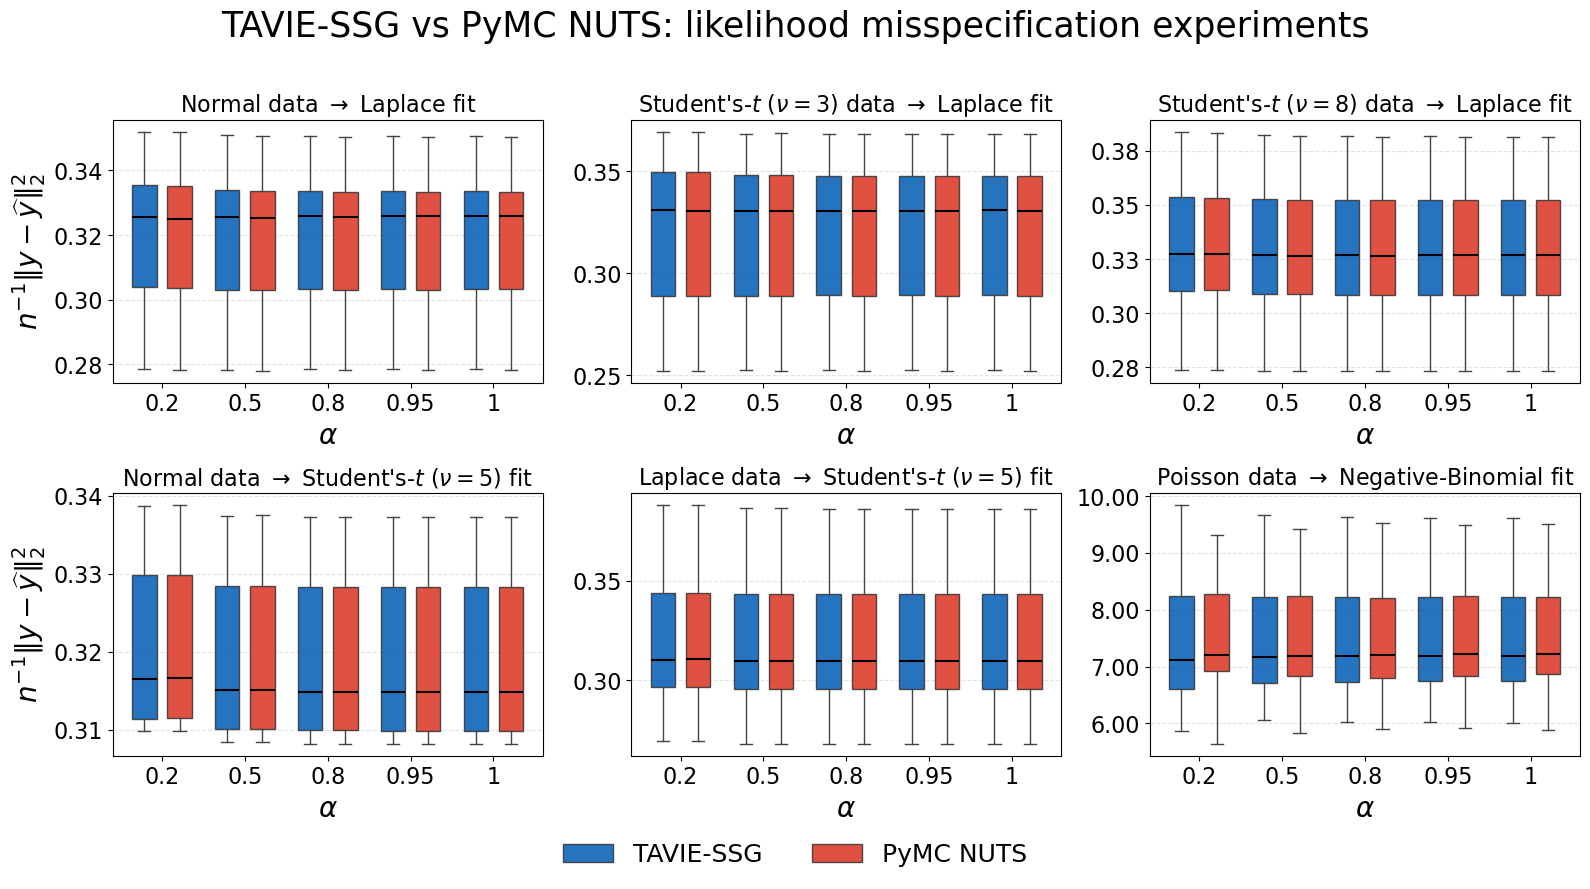

In [34]:
# Plot-formatting controls; changing these does not require rerunning the simulations.
from matplotlib.ticker import FormatStrFormatter

FIGSIZE = (16, 9)
SHOW_FLIERS = False
SAVE_FIGURES = True
METHOD_COLORS = {
    "TAVIE-SSG": "#005AB5",
    "PyMC NUTS": "#DC3220",
}

alpha_centers = np.arange(len(plot_alphas), dtype=float)
group_width = 0.72
box_width = group_width / len(plot_methods) * 0.82
method_offsets = np.linspace(
    -group_width / 2 + box_width / 2,
    group_width / 2 - box_width / 2,
    len(plot_methods),
)

# The count-response MSE is on a different scale, so panels have independent y-axes.
fig, axes = plt.subplots(2, 3, figsize=FIGSIZE, sharey=False)
axes = axes.ravel()

plot_titles = [
    r"Normal data $\rightarrow$ Laplace fit",
    r"Student's-$t$ ($\nu=3$) data $\rightarrow$ Laplace fit",
    r"Student's-$t$ ($\nu=8$) data $\rightarrow$ Laplace fit",
    r"Normal data $\rightarrow$ Student's-$t$ ($\nu=5$) fit",
    r"Laplace data $\rightarrow$ Student's-$t$ ($\nu=5$) fit",
    r"Poisson data $\rightarrow$ Negative-Binomial fit",
]

for ax, spec, title in zip(axes, plot_experiments, plot_titles):
    case_df = plot_df.loc[plot_df["experiment"] == spec["key"]]

    for method, offset in zip(plot_methods, method_offsets):
        method_df = case_df.loc[case_df["method"] == method]
        mse_by_alpha = [
            method_df.loc[np.isclose(method_df["alpha"], alpha), "mse"].to_numpy()
            for alpha in plot_alphas
        ]
        assert all(len(values) == plot_config["n_reps"] for values in mse_by_alpha)

        boxplot = ax.boxplot(
            mse_by_alpha,
            positions=alpha_centers + offset,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=SHOW_FLIERS,
            medianprops={"color": "black", "linewidth": 1.5},
            whiskerprops={"color": "#444444", "linewidth": 1.0},
            capprops={"color": "#444444", "linewidth": 1.0},
        )
        for box in boxplot["boxes"]:
            box.set_facecolor(METHOD_COLORS[method])
            box.set_edgecolor("#333333")
            box.set_alpha(0.85)

    ax.set_xticks(alpha_centers)
    ax.set_xticklabels([f"{alpha:g}" for alpha in plot_alphas], fontsize=16)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(r"$\alpha$", fontsize=20)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.tick_params(axis="y", labelsize=16)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

for ax in (axes[0], axes[3]):
    ax.set_ylabel(r"$n^{-1}\|y-\widehat y\|_2^2$", fontsize=20)

legend_handles = [
    Patch(facecolor=METHOD_COLORS[method], edgecolor="#333333", label=method, alpha=0.85)
    for method in plot_methods
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(plot_methods),
    frameon=False,
    fontsize=18,
)

fig.suptitle(
    f"TAVIE-SSG vs PyMC NUTS: likelihood misspecification experiments",
    # f"(n={plot_config['n']}, {plot_config['n_reps']} repetitions)",
    fontsize=25,
)
fig.tight_layout(rect=(0, 0.06, 1, 0.96))

if SAVE_FIGURES:
    figure_stem = (
        RESULTS_DIR / "tavie_ssg_misspecification_six_experiments_mse_boxplots"
    )
    fig.savefig(figure_stem.with_suffix(".pdf"), bbox_inches="tight")

plt.show()